In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
warnings.filters()
dataset = pd.read_csv(r"C:\Users\hp\Desktop\14 Days 14 Models\Day 3\medical_insurance_cost_dataset.csv")
dataset.head(3)

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_usd,exercise_level,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,insurance_plan,annual_medical_cost_usd
0,MIC100001,56,Male,25.2,2,Yes,Northeast,Driver,77885,Moderate,0,2,0,13,Basic,24353.46
1,MIC100002,29,Male,25.7,1,Yes,Northwest,Doctor,18000,High,0,2,0,3,Standard,22530.60
2,MIC100003,20,Male,30.1,1,No,Central,Teacher,85811,Low,1,5,0,1,Standard,13393.16


In [31]:
dataset.isnull().sum()

customer_id                     0
age                             0
gender                          0
bmi                             0
children                        0
smoker                          0
region                          0
occupation                      0
annual_income_usd               0
exercise_level                  0
chronic_diseases                0
doctor_visits_per_year          0
hospitalizations_last_year      0
alcohol_consumption_per_week    0
insurance_plan                  0
annual_medical_cost_usd         0
dtype: int64

In [32]:
dataset.duplicated().sum()

np.int64(0)

In [33]:
dataset.drop("customer_id", axis = 1, inplace = True)

In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           7500 non-null   int64  
 1   gender                        7500 non-null   object 
 2   bmi                           7500 non-null   float64
 3   children                      7500 non-null   int64  
 4   smoker                        7500 non-null   object 
 5   region                        7500 non-null   object 
 6   occupation                    7500 non-null   object 
 7   annual_income_usd             7500 non-null   int64  
 8   exercise_level                7500 non-null   object 
 9   chronic_diseases              7500 non-null   int64  
 10  doctor_visits_per_year        7500 non-null   int64  
 11  hospitalizations_last_year    7500 non-null   int64  
 12  alcohol_consumption_per_week  7500 non-null   int64  
 13  ins

In [35]:
num_col = dataset.select_dtypes(include = ["int64", "float64"]).columns
cat_col = dataset.select_dtypes(include = "object").columns

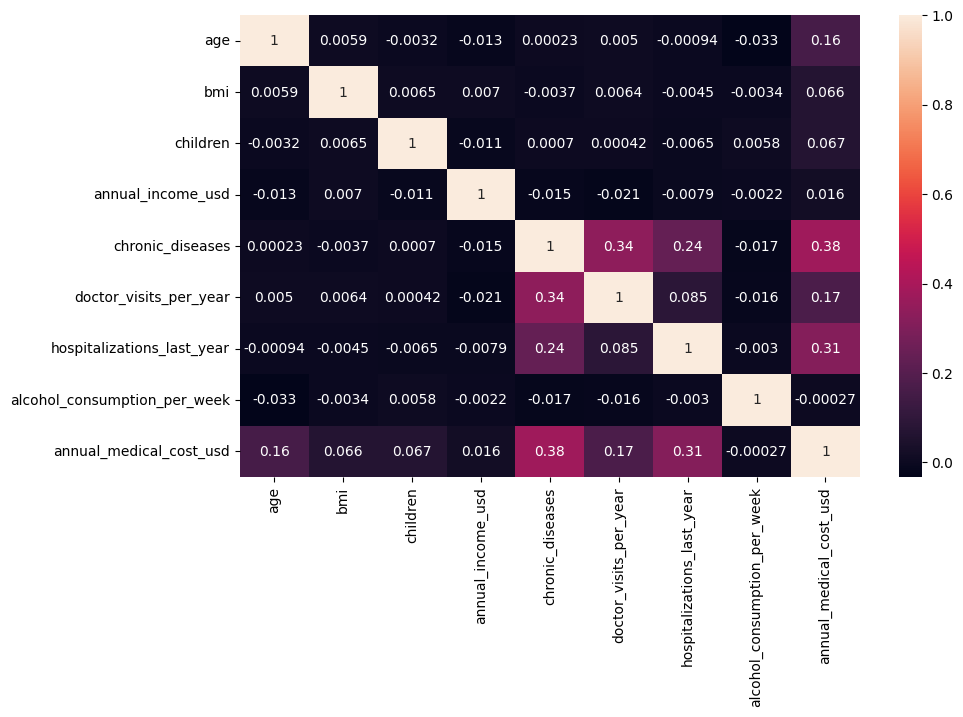

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(dataset[num_col].corr(), annot = True)
plt.show()

In [37]:
for col in cat_col:
    print(f"The {col} have {dataset[col].unique()} unique values.")

The gender have ['Male' 'Female'] unique values.
The smoker have ['Yes' 'No'] unique values.
The region have ['Northeast' 'Northwest' 'Central' 'Southeast' 'Southwest'] unique values.
The occupation have ['Driver' 'Doctor' 'Teacher' 'Engineer' 'Nurse' 'Lawyer' 'Office Worker'
 'Construction Worker' 'Technician' 'Manager' 'Retail Worker'] unique values.
The exercise_level have ['Moderate' 'High' 'Low'] unique values.
The insurance_plan have ['Basic' 'Standard' 'Premium' 'Gold'] unique values.


In [38]:
X = dataset.drop("annual_medical_cost_usd", axis = 1)
y = dataset["annual_medical_cost_usd"]

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.20, random_state = 42)

In [ ]:
# Applying ColumnTransformer and Encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ct = ColumnTransformer([
    ("ohe", OneHotEncoder(sparse_output = False, drop = "first"), ["gender", "smoker", "occupation", "region"]),
    ("ordinal_enc", OrdinalEncoder(categories = [["Moderate", "High", "Low"], ["Basic", "Standard", "Premium", "Gold"]]), ["exercise_level", "insurance_plan"])
])

ct.fit(X_train)
X_train = ct.transform(X_train)
X_test = ct.transform(X_test)


In [41]:
# Scaling

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(X_train)
X_train =  ss.transform(X_train)
X_test = ss.transform(X_test)

In [42]:
# Dataset training

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
lr.score(X_test, y_test)*100

63.070361683162645

In [ ]:
# Try Tree models


from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor

dtr = DecisionTreeRegressor(max_depth=4)

dtr.fit(X_train, y_train)

dtr.score(X_test, y_test)

0.6674747916608593

In [ ]:
# ExtraTreeRegressor
etr = ExtraTreeRegressor(max_depth = 4)

etr.fit(X_train, y_train)
etr.score(X_test, y_test)

0.6392232803002419

In [52]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

rfr = RandomForestRegressor(max_depth=4)

rfr.fit(X_train, y_train)

rfr.score(X_test, y_test)

0.6676408166984062

In [54]:
ada = AdaBoostRegressor()

ada.fit(X_train, y_train)

ada.score(X_test, y_test)

0.6516624009203436

In [57]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train, y_train)
xgb.score(X_test, y_test)

0.6161342115868211

In [58]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor()

lgbm.fit(X_train, y_train)
lgbm.score(X_test, y_test)

c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.6545472256847353

In [ ]:
from catboost import 